<a href="https://colab.research.google.com/github/MeerMusabih/FlyRank-AI-Internship/blob/main/work/notebooks/w05_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MeerMusabih/FlyRank-AI-Internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

I selected a Random Forest classifier for this modeling task.

The goal of this lane is to prioritize content pages for refresh review. The Week-4 baseline uses a simple rule-based score, while the learned model can combine several observed content, traffic, freshness, and engagement signals.

Random Forest fits the task because it can capture non-linear relationships and interactions between these structured signals while still providing feature importance for interpretation. It is also a reasonable next step from a simple rule baseline because the purpose is to test whether a learned model provides a useful improvement rather than adding complexity for its own sake.

The target is `is_declining_label`, which indicates whether the observed trend direction is down.

To avoid leakage, `trend_direction` and `trend_pct` are excluded. The 30-day comparison columns used to construct the trend label are also excluded because they directly contain the information used to create the target.

The model is used as decision support: its probability of decline is used to rank pages for review rather than automatically deciding that a page must be refreshed.

In [1]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head()

Rows: 30000
Columns: 44


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


### Target and leakage checks

The target is `is_declining_label`.

The following fields are not used as model features:

- `is_declining_label` — target
- `trend_direction` — source of the target
- `trend_pct` — directly used to define the trend direction
- `impressions_last_30d`
- `clicks_last_30d`
- `sessions_last_30d`
- `impressions_prev_30d`
- `clicks_prev_30d`
- `sessions_prev_30d`

The six comparison-window fields are excluded because the target is constructed from the recent-vs-previous impression trend. Including them would allow the model to learn the label from the same information used to create it.

Identifiers are also excluded from the feature matrix. `client_id` is retained separately for grouped validation.

In [2]:
TARGET = "is_declining_label"
df[TARGET] = (
    df["trend_direction"] == "down"
).astype(int)

print("Target distribution:")
print(df[TARGET].value_counts())

print("\nTarget rate:")
print(df[TARGET].mean())

ID_COLUMNS = [
    "content_id",
    "client_id"
]

LEAKAGE_COLUMNS = [
    "trend_direction",
    "trend_pct",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d"
]

NON_FEATURE_COLUMNS = [
    "provider_used",
    "model_used"
]

excluded_columns = (
    [TARGET]
    + ID_COLUMNS
    + LEAKAGE_COLUMNS
    + NON_FEATURE_COLUMNS
)

feature_columns = [
    col for col in df.columns
    if col not in excluded_columns
]

X = df[feature_columns].copy()
y = df[TARGET].astype(int).copy()
groups = df["client_id"].copy()

print("Number of features:", len(feature_columns))
print("Target distribution:")
print(y.value_counts())
print("\nTarget rate:")
print(y.mean())

Target distribution:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64

Target rate:
0.5420666666666667
Number of features: 32
Target distribution:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64

Target rate:
0.5420666666666667


## 2. Split design

I use a client-grouped train/test split.

The dataset contains multiple content pages from the same pseudonymized client. A random row-level split could place pages from the same client in both training and testing, allowing client-specific patterns to appear in both sets.

Instead, `client_id` is used only for grouping. Entire clients are assigned to either the training or test set.

This gives a more honest estimate of how the model performs on clients it did not see during training.

The split is fixed with `random_state=42` so the experiment is reproducible.

In [3]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("\nTraining clients:", groups_train.nunique())
print("Test clients:", groups_test.nunique())

print("\nClient overlap:")
print(set(groups_train).intersection(set(groups_test)))

print("\nTraining target rate:", round(y_train.mean(), 4))
print("Test target rate:", round(y_test.mean(), 4))

Training rows: 23837
Test rows: 6163

Training clients: 25
Test clients: 7

Client overlap:
set()

Training target rate: 0.5501
Test target rate: 0.511


## 3. Train + compare vs my baseline

The Week-4 baseline is the rule-based refresh score from ML-07:

- +2 for content that has not been updated for at least 180 days
- +1 for at least 500 impressions in the last 30 days
- +1 for average position greater than 10

Higher scores produce higher refresh priority.

Because this baseline produces a ranked queue rather than a binary prediction, the comparison uses Precision@20 and Precision@50. These metrics ask how many of the highest-priority pages are actually observed as declining.

The Random Forest produces a probability of decline, which is also used as a ranking score.

Both methods are evaluated on the same held-out test pages.

In [4]:
numeric_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 23
Categorical features: 9


In [5]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median", add_indicator=True)
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

In [6]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"
)

rf_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        model
    )
])

rf_pipeline.fit(X_train, y_train)

rf_probability = rf_pipeline.predict_proba(
    X_test
)[:, 1]

print("Model trained successfully.")

Model trained successfully.


In [7]:
model_results = df.iloc[test_idx][
    ["content_id", "client_id"]
].copy()

model_results["actual"] = y_test.values
model_results["model_score"] = rf_probability

model_results = model_results.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

model_results.head(10)

,content_id,client_id,actual,model_score
0,content_98aa0aecb1d9,client_8527a891e2,1,0.973333
1,content_e988c1699454,client_8527a891e2,1,0.973333
2,content_2ba626fea4d6,client_8527a891e2,0,0.973333
3,content_9ac61c04930e,client_8527a891e2,1,0.973333
4,content_7a6cb4857fe6,client_f369cb89fc,1,0.950000
5,content_500bd3907331,client_4e07408562,0,0.946667
6,content_1d0963b56227,client_4e07408562,0,0.946667
7,content_cb372c0a7708,client_4e07408562,1,0.946667
8,content_db74537c5636,client_8527a891e2,1,0.943333
9,content_35d63627bf3e,client_8527a891e2,0,0.943333


In [8]:
baseline_test = df.iloc[test_idx].copy()

stale = (
    baseline_test["days_since_last_update"] >= 180
).astype(int)

visible = (
    baseline_test["impressions_last_30d"] >= 500
).astype(int)

low_position = (
    baseline_test["avg_position"] > 10
).astype(int)

baseline_test["baseline_score"] = (
    stale * 2 +
    visible +
    low_position
)

baseline_results = baseline_test[
    ["content_id", "client_id", TARGET, "baseline_score"]
].copy()

baseline_results = baseline_results.rename(
    columns={TARGET: "actual"}
)

baseline_results = baseline_results.sort_values(
    "baseline_score",
    ascending=False
).reset_index(drop=True)

baseline_results.head(10)

,content_id,client_id,actual,baseline_score
0,content_406db3266689,client_4e07408562,1,2
1,content_fb937217a0d0,client_4e07408562,1,2
2,content_94ff4ec6b6b5,client_4e07408562,1,2
3,content_b27403c7d35e,client_4e07408562,0,2
4,content_2851eb1b0839,client_4e07408562,1,2
5,content_9e910c76fe4c,client_4e07408562,0,2
6,content_27b5f3558e46,client_4e07408562,0,2
7,content_d1f3eb45593b,client_4e07408562,0,2
8,content_7dfafed821a2,client_f369cb89fc,1,2
9,content_ce9d0e4e4dd2,client_4e07408562,0,2


In [9]:
def precision_at_k(ranked_df, k):
    top_k = ranked_df.head(k)
    return top_k["actual"].mean()


ks = [20, 50]

comparison_rows = []

for k in ks:
    comparison_rows.append({
        "Metric": f"Precision@{k}",
        "ML-07 Baseline": precision_at_k(
            baseline_results,
            k
        ),
        "Random Forest": precision_at_k(
            model_results,
            k
        )
    })

comparison = pd.DataFrame(comparison_rows)

comparison

,Metric,ML-07 Baseline,Random Forest
0,Precision@20,0.40,0.70
1,Precision@50,0.36,0.68


### Results

The Random Forest produced higher precision than the ML-07 rule-based baseline at both review sizes.

At Precision@20, the baseline achieved 0.40 while the Random Forest achieved 0.70. This means 14 of the model's top 20 ranked pages were observed as declining, compared with 8 of the baseline's top 20.

At Precision@50, the baseline achieved 0.36 while the Random Forest achieved 0.68. This corresponds to 34 observed declining pages in the model's top 50, compared with 18 for the baseline.

The measured results suggest that the Random Forest provides a stronger ranking of potential review candidates than the simple rule on this held-out client set. This is evidence of improved decision-support performance on this evaluation, not proof that refreshing these pages will improve future SEO outcomes.

In [10]:
base_rate = y_test.mean()

print(
    f"Test-set declining base rate: "
    f"{base_rate:.3f} ({base_rate:.1%})"
)

Test-set declining base rate: 0.511 (51.1%)


### Baseline vs model

The comparison table above uses the same held-out test pages for both approaches.

Precision@K is interpreted as the proportion of pages in the top K ranked recommendations that have the observed declining label.

The test-set base rate is shown as context. A useful ranking should be interpreted relative to this observed rate rather than by looking at the precision value alone.

The Random Forest is considered useful only if its ranking provides a meaningful improvement over the simple ML-07 rule, especially at the review sizes that matter for decision support.

## 4. Errors and interpretation

I inspect both model errors and feature importance before deciding whether the model is useful.

For a ranking model, an important error is a page that receives a high predicted decline probability but is not observed as declining. The opposite error is a page that is observed as declining but receives a relatively low score.

Three concrete test-set errors are inspected below rather than relying only on aggregate metrics.

In [11]:
error_analysis = df.iloc[test_idx][
    [
        "content_id",
        "client_id",
        "is_declining_label",
        "content_age_days",
        "days_since_last_update",
        "impressions_90d",
        "clicks_90d",
        "sessions_90d",
        "ctr",
        "avg_position"
    ]
].copy()

error_analysis["model_score"] = rf_probability

error_analysis["predicted"] = (
    error_analysis["model_score"] >= 0.5
).astype(int)

false_positives = error_analysis[
    (error_analysis["predicted"] == 1) &
    (error_analysis["is_declining_label"] == 0)
].sort_values(
    "model_score",
    ascending=False
)

false_negatives = error_analysis[
    (error_analysis["predicted"] == 0) &
    (error_analysis["is_declining_label"] == 1)
].sort_values(
    "model_score",
    ascending=True
)

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

False positives: 1557
False negatives: 1078


In [12]:
three_errors = pd.concat([
    false_positives.head(2),
    false_negatives.head(1)
])

three_errors[
    [
        "content_id",
        "is_declining_label",
        "model_score",
        "content_age_days",
        "days_since_last_update",
        "impressions_90d",
        "clicks_90d",
        "sessions_90d",
        "ctr",
        "avg_position"
    ]
]

,content_id,is_declining_label,model_score,content_age_days,days_since_last_update,impressions_90d,clicks_90d,sessions_90d,ctr,avg_position
22042,content_2ba626fea4d6,0,0.973333,275,104,360,0,3,0.00,7.2
22526,content_1d0963b56227,0,0.946667,280,104,3445,3,5,0.09,39.0
1864,content_16f38acf0f26,1,0.080000,358,20,2,0,2,0.00,50.0


In [13]:
fitted_preprocessor = rf_pipeline.named_steps["preprocessor"]
fitted_model = rf_pipeline.named_steps["model"]

feature_names = fitted_preprocessor.get_feature_names_out()

importances = pd.Series(
    fitted_model.feature_importances_,
    index=feature_names
).sort_values(
    ascending=False
)

top_features = importances.head(10)

top_features

,0
numeric__impressions_90d,0.088723
numeric__avg_position,0.087791
numeric__days_with_impressions,0.077055
numeric__content_age_days,0.062694
numeric__char_count,0.046261
numeric__word_count,0.045465
numeric__ctr,0.043675
numeric__pageviews_90d,0.041135
numeric__scroll_rate,0.040034
numeric__days_with_sessions,0.038476


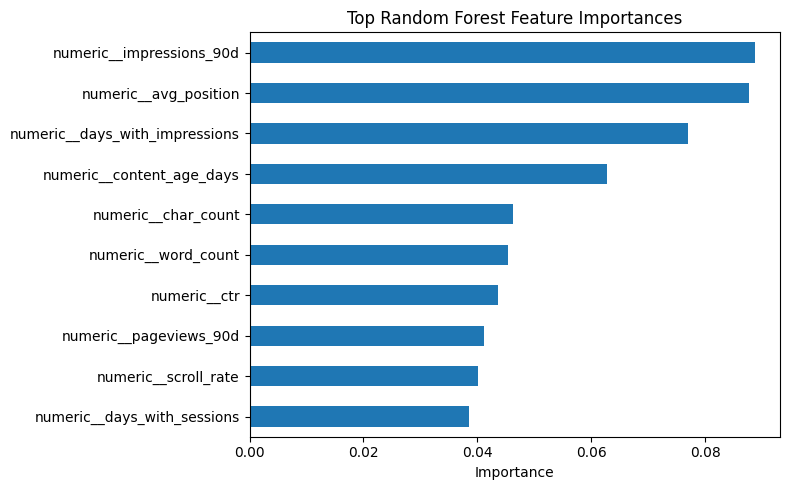

In [14]:
import matplotlib.pyplot as plt

top_features.sort_values().plot.barh(
    figsize=(8, 5)
)

plt.title("Top Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Feature interpretation

The three strongest observed features in the fitted Random Forest were:

1. **Impressions over the 90-day window (`impressions_90d`)** — This was the strongest measured feature. It represents the amount of search visibility a page received and therefore provides useful context about the page's observed search performance.

2. **Average search position (`avg_position`)** — This was nearly as important as impressions. Search position is directly related to how prominently a page appears in search results, making it a plausible signal when distinguishing pages with different performance patterns.

3. **Days with impressions (`days_with_impressions`)** — This measures how consistently a page received search impressions during the 90-day window. A page with impressions across more days has a different observed performance pattern from a page with only occasional visibility.

These are associations rather than causal effects. The feature importances show which observed signals the Random Forest relied on when separating the two target classes; they do not establish that changing any of these features would cause a page to decline or improve.

No client or content identifiers appear among the strongest features, and the direct trend-label fields were excluded from the feature matrix.

### Error interpretation

The three inspected errors show that the classes are not perfectly separable from the available observed signals.

The two false-positive examples received relatively high model scores but were not labeled as declining. Both had combinations of older content, time since last update, and search-performance signals that resembled pages in the declining group.

The false-negative example was observed as declining but received a lower model score. This page had very low search visibility and engagement, suggesting that low-volume pages can be harder for the model to classify correctly from the available signals.

These errors are important because they show that the model should be treated as decision support rather than an automatic refresh decision.


### Final Finding

The Random Forest outperformed the ML-07 baseline at both tested review sizes. Its measured Precision@20 was 0.70 compared with 0.40 for the baseline, while Precision@50 was 0.68 compared with 0.36.

The improvement was consistent across both review sizes, suggesting that the learned model provides a more useful ranking of observed declining pages than the simple rule-based score on the held-out clients.

However, these results should be interpreted as directional decision-support evidence. The evaluation measures agreement with the observed declining label; it does not establish that a content refresh will cause improved traffic, rankings, or engagement.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.